In [1]:
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open from the project root or prediction folder.")
sys.path.insert(0, str(ROOT))

from src.data_preparation import prepare_data
from src.train import run_training
from src.evaluate import evaluate_artifacts
from src.predict import forecast_latest
from src.data_loader import read_data


In [2]:
data = prepare_data()
for split in ("train", "val", "test"):
    print(split, data[split]["X"].shape)
print("Features:", data["feature_columns"])


train (1002, 60, 19)
val (225, 60, 19)
test (225, 60, 19)
Features: ['SP500_return', 'DGS10_return', 'UNRATE_return', 'CPIAUCSL_return', 'DCOILWTICO_return', 'NASDAQCOM_return', 'SP500_MA5_ratio', 'SP500_MA20_ratio', 'SP500_MA50_ratio', 'SP500_Vol_5', 'SP500_Vol_20', 'SP500_Momentum_5', 'NASDAQ_Momentum_5', 'SP500_Momentum_20', 'NASDAQ_Momentum_20', 'SP500_Momentum_60', 'NASDAQ_Momentum_60', 'Yield_Change_5', 'Oil_Change_5']


c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:14: UserWarning: CSV dates are unsorted. Inspect whether values were filled before sorting.
  warnings.warn("CSV dates are unsorted. Inspect whether values were filled before sorting.")
c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:25: UserWarning: SP500 changes exceed 30%. Inspect source data before interpreting metrics.
  warnings.warn("SP500 changes exceed 30%. Inspect source data before interpreting metrics.")


In [3]:
artifact_dir = ROOT / "models" / "returns_v1"
run_training(output_dir=artifact_dir)


c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:14: UserWarning: CSV dates are unsorted. Inspect whether values were filled before sorting.
  warnings.warn("CSV dates are unsorted. Inspect whether values were filled before sorting.")
c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:25: UserWarning: SP500 changes exceed 30%. Inspect source data before interpreting metrics.
  warnings.warn("SP500 changes exceed 30%. Inspect source data before interpreting metrics.")


train: (1002, 60, 19)
val: (225, 60, 19)
test: (225, 60, 19)
lstm | Epoch 01 | Train 1.0153 | Val 0.2905
lstm | Epoch 02 | Train 0.9882 | Val 0.2895
lstm | Epoch 03 | Train 0.9754 | Val 0.2818
lstm | Epoch 04 | Train 0.9548 | Val 0.2791
lstm | Epoch 05 | Train 0.9556 | Val 0.2777
lstm | Epoch 06 | Train 0.9503 | Val 0.2782
lstm | Epoch 07 | Train 0.9483 | Val 0.2770
lstm | Epoch 08 | Train 0.9462 | Val 0.2777
lstm | Epoch 09 | Train 0.9454 | Val 0.2814
lstm | Epoch 10 | Train 0.9424 | Val 0.2772
lstm | Epoch 11 | Train 0.9430 | Val 0.2729
lstm | Epoch 12 | Train 0.9447 | Val 0.2887
lstm | Epoch 13 | Train 0.9424 | Val 0.2796
lstm | Epoch 14 | Train 0.9346 | Val 0.3083
lstm | Epoch 15 | Train 0.9295 | Val 0.2768
lstm | Epoch 16 | Train 0.9184 | Val 0.2801
lstm | Epoch 17 | Train 0.8982 | Val 0.2753
lstm | Epoch 18 | Train 0.8745 | Val 0.2757
Early stopping at epoch 18


c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\models.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


transformer | Epoch 01 | Train 1.0167 | Val 0.2999
transformer | Epoch 02 | Train 0.9823 | Val 0.2790
transformer | Epoch 03 | Train 0.9659 | Val 0.2774
transformer | Epoch 04 | Train 0.9542 | Val 0.2801
transformer | Epoch 05 | Train 0.9506 | Val 0.2806
transformer | Epoch 06 | Train 0.9518 | Val 0.2771
transformer | Epoch 07 | Train 0.9495 | Val 0.2774
transformer | Epoch 08 | Train 0.9449 | Val 0.2815
transformer | Epoch 09 | Train 0.9479 | Val 0.2772
transformer | Epoch 10 | Train 0.9448 | Val 0.2750
transformer | Epoch 11 | Train 0.9374 | Val 0.2809
transformer | Epoch 12 | Train 0.9383 | Val 0.2739
transformer | Epoch 13 | Train 0.9374 | Val 0.2854
transformer | Epoch 14 | Train 0.9238 | Val 0.2747
transformer | Epoch 15 | Train 0.9206 | Val 0.3017
transformer | Epoch 16 | Train 0.9215 | Val 0.2766
transformer | Epoch 17 | Train 0.9117 | Val 0.2748
transformer | Epoch 18 | Train 0.9266 | Val 0.3009
transformer | Epoch 19 | Train 0.8957 | Val 0.2798
Early stopping at epoch 19
Arti

WindowsPath('c:/Users/Али Айнур/Desktop/sp500_prediction_DL/models/returns_v1')

In [4]:
overall, by_horizon = evaluate_artifacts(artifact_dir)
display(overall)
display(by_horizon)


                 MAE      RMSE    MAPE      R2
Naive        58.1498  105.7297  1.3391  0.7676
Lstm         55.4393   90.3101  1.2801  0.8304
Transformer  55.7253   95.0640  1.2830  0.8121
      Model  Day     MAE     RMSE   MAPE     R2
      Naive    1 38.1204  88.5245 0.8764 0.8331
       Lstm    1 40.0793  77.3501 0.9274 0.8725
Transformer    1 35.8536  76.1131 0.8213 0.8766
      Naive    2 51.1246  99.4201 1.1790 0.7923
       Lstm    2 49.5159  86.7628 1.1479 0.8418
Transformer    2 49.2386  88.2181 1.1349 0.8364
      Naive    3 59.8991 106.6566 1.3802 0.7641
       Lstm    3 56.3114  90.6378 1.3030 0.8297
Transformer    3 57.4597  95.4454 1.3234 0.8111
      Naive    4 67.6932 113.9639 1.5593 0.7330
       Lstm    4 62.5723  96.2644 1.4421 0.8095
Transformer    4 64.3158 103.0133 1.4815 0.7819
      Naive    5 73.9115 117.5138 1.7003 0.7180
       Lstm    5 68.7178  98.9279 1.5802 0.8002
Transformer    5 71.7587 109.0351 1.6541 0.7572


c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\models.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


,MAE,RMSE,MAPE,R2
Naive,58.149769,105.729709,1.339056,0.767566
Lstm,55.439341,90.310144,1.280140,0.830418
Transformer,55.725285,95.064028,1.283049,0.812095


,Model,Day,MAE,RMSE,MAPE,R2
0,Naive,1,38.120444,88.524535,0.876438,0.833055
1,Lstm,1,40.079256,77.350119,0.927432,0.872542
2,Transformer,1,35.853617,76.113058,0.821314,0.876586
3,Naive,2,51.124622,99.420108,1.179012,0.792255
4,Lstm,2,49.515940,86.762822,1.147868,0.841784
5,Transformer,2,49.238607,88.218106,1.134904,0.836432
6,Naive,3,59.899067,106.656579,1.380195,0.764117
7,Lstm,3,56.311376,90.637801,1.303047,0.829651
8,Transformer,3,57.459650,95.445352,1.323406,0.811100
9,Naive,4,67.693244,113.963932,1.559326,0.733016


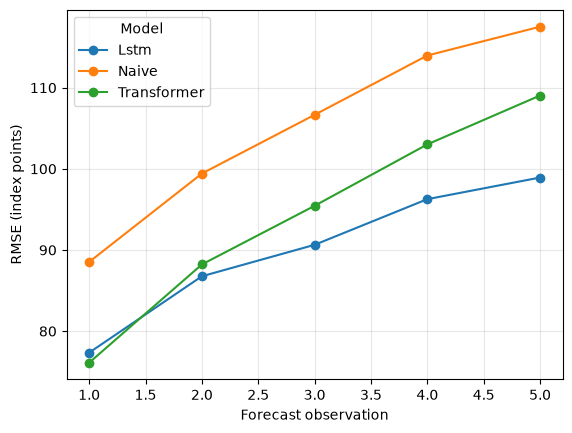

In [5]:
by_horizon.pivot(index="Day", columns="Model", values="RMSE").plot(marker="o")
plt.ylabel("RMSE (index points)")
plt.xlabel("Forecast observation")
plt.grid(alpha=0.3)
plt.show()


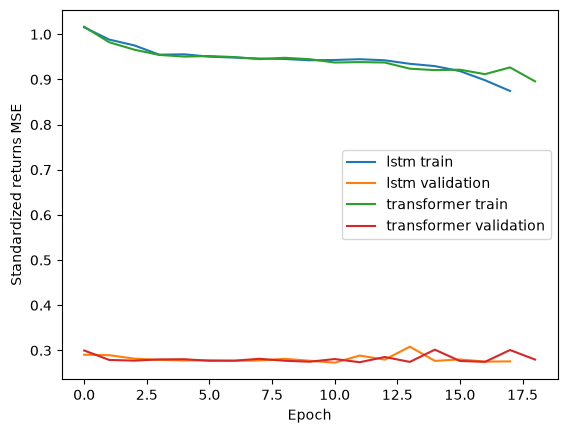

In [6]:
histories = json.loads((artifact_dir / "history.json").read_text())
for name, history in histories.items():
    plt.plot(history["train"], label=f"{name} train")
    plt.plot(history["val"], label=f"{name} validation")
plt.legend()
plt.ylabel("Standardized returns MSE")
plt.xlabel("Epoch")
plt.show()


In [7]:
forecast_latest(read_data(), artifact_dir)


c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:14: UserWarning: CSV dates are unsorted. Inspect whether values were filled before sorting.
  warnings.warn("CSV dates are unsorted. Inspect whether values were filled before sorting.")
c:\Users\Али Айнур\Desktop\sp500_prediction_DL\src\data_loader.py:25: UserWarning: SP500 changes exceed 30%. Inspect source data before interpreting metrics.
  warnings.warn("SP500 changes exceed 30%. Inspect source data before interpreting metrics.")


{'model': 'lstm',
 'as_of': '2023-12-29 00:00:00',
 'last_price': 4769.83,
 'predicted_returns': [0.003929658327251673,
  -0.00030618440359830856,
  -0.0013991843443363905,
  -0.002598461462184787,
  -0.0009581788908690214],
 'predicted_index': [4788.5735956144335,
  4787.107155464888,
  4780.408952687979,
  4767.987141324282,
  4763.418375678062]}